In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Load the dataset (update path after downloading)
df = pd.read_csv("/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment_Rate_upto_11_2020.csv")  


print(df.head())
print(df.info())
print(df.isnull().sum())

# Clean column names (remove spaces)
df.columns = df.columns.str.strip()

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Drop rows with missing critical values
df = df.dropna(subset=['Date', 'Estimated Unemployment Rate (%)'])

# Sort by Region and Date
df = df.sort_values(by=['Region', 'Date'])

# Check for duplicates
df = df.drop_duplicates()

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-01-2020          M                              5.48   
1  Andhra Pradesh   29-02-2020          M                              5.83   
2  Andhra Pradesh   31-03-2020          M                              5.79   
3  Andhra Pradesh   30-04-2020          M                             20.51   
4  Andhra Pradesh   31-05-2020          M                             17.43   

    Estimated Employed   Estimated Labour Participation Rate (%) Region.1  \
0             16635535                                     41.02    South   
1             16545652                                     40.90    South   
2             15881197                                     39.18    South   
3             11336911                                     33.10    South   
4             12988845                                     36.46    South   

   longitude  latitude  
0    15.9129     79.74  
1    15.9129

# Exploratory Data Analysis

count    267.000000
mean      12.236929
std       10.803283
min        0.500000
25%        4.845000
50%        9.650000
75%       16.755000
max       75.850000
Name: Estimated Unemployment Rate (%), dtype: float64
Region
Meghalaya            3.866000
Assam                4.856000
Gujarat              6.376000
Odisha               6.462000
Telangana            6.833000
Madhya Pradesh       6.854000
Karnataka            7.668000
Chhattisgarh         7.819000
Maharashtra          7.979000
Andhra Pradesh       8.664000
Kerala               9.434000
Uttar Pradesh        9.737000
Sikkim               9.792500
West Bengal         10.192000
Uttarakhand         11.156000
Punjab              11.981000
Goa                 12.167000
Tamil Nadu          12.187000
Rajasthan           15.868000
Himachal Pradesh    16.065000
Jammu & Kashmir     16.477778
Puducherry          17.942000
Delhi               18.414000
Bihar               19.471000
Jharkhand           19.539000
Tripura             25.055000

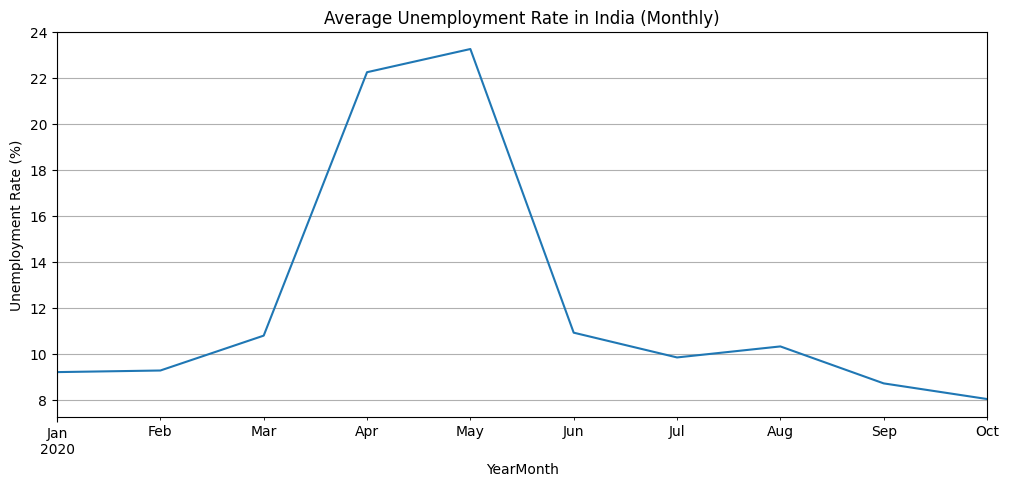

In [22]:

print(df['Estimated Unemployment Rate (%)'].describe())

# Unemployment rate by region (average)
region_unemp = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values()
print(region_unemp)

# Overall time trend – monthly average
df['YearMonth'] = df['Date'].dt.to_period('M')
monthly_unemp = df.groupby('YearMonth')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12,5))
monthly_unemp.plot()
plt.title("Average Unemployment Rate in India (Monthly)")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

# Impact of COVID-19

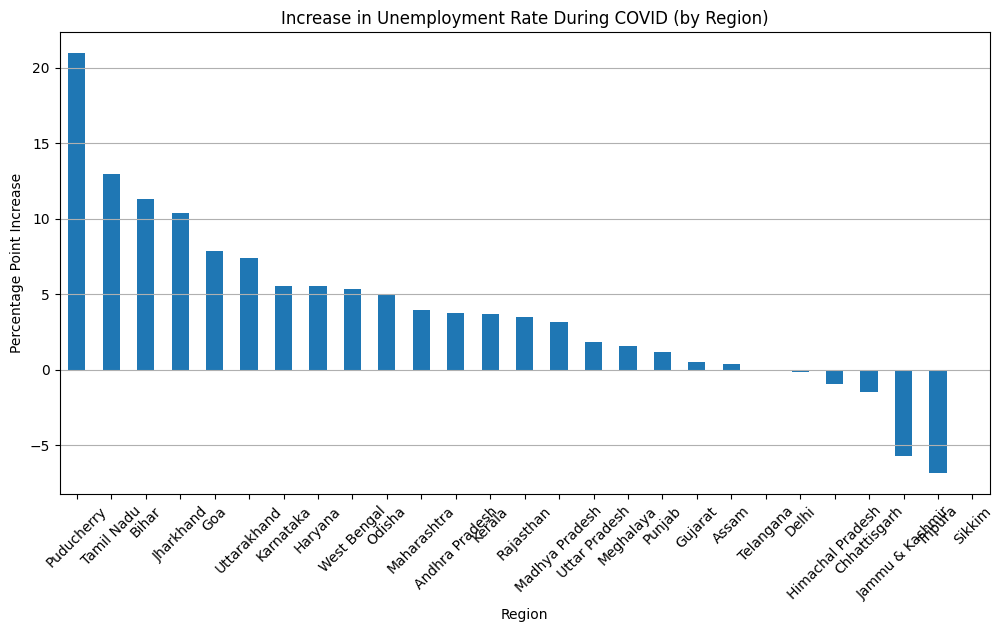

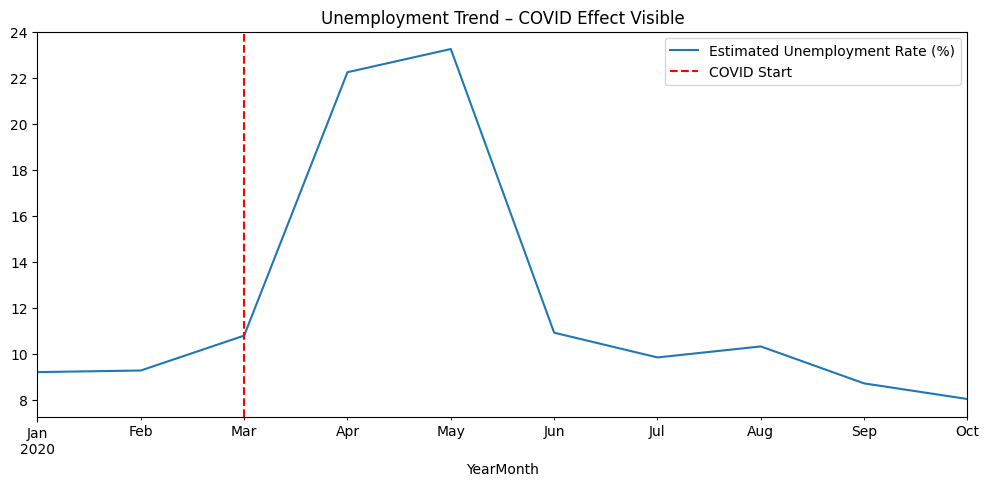

In [23]:
# Mark COVID period
df['IsCOVID'] = df['Date'] >= '2020-03-01'

regional_covid = df.groupby(['Region', 'IsCOVID'])['Estimated Unemployment Rate (%)'].mean().unstack()
regional_covid['Change'] = regional_covid[True] - regional_covid[False]
regional_covid = regional_covid.sort_values('Change', ascending=False)

# Plot regional changes
plt.figure(figsize=(12,6))
regional_covid['Change'].plot(kind='bar')
plt.title("Increase in Unemployment Rate During COVID (by Region)")
plt.ylabel("Percentage Point Increase")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

# National monthly trend highlighting COVID
plt.figure(figsize=(12,5))
monthly_unemp.plot()
plt.axvline(x=pd.Timestamp('2020-03-01'), color='red', linestyle='--', label='COVID Start')
plt.title("Unemployment Trend – COVID Effect Visible")
plt.legend()
plt.show()

# Identify Seasonal Patterns

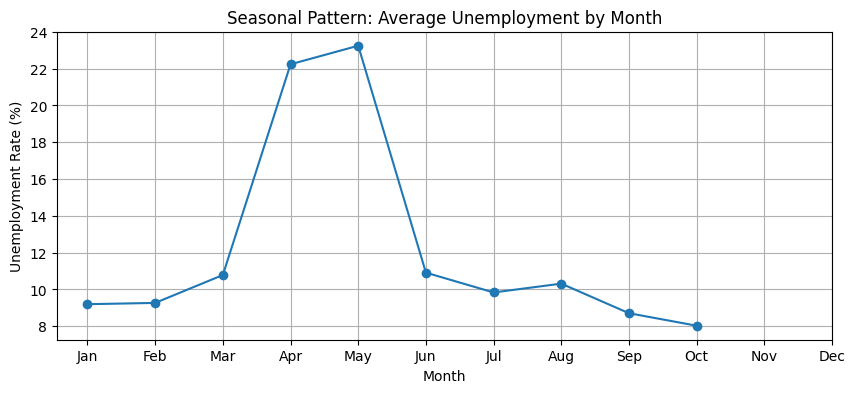

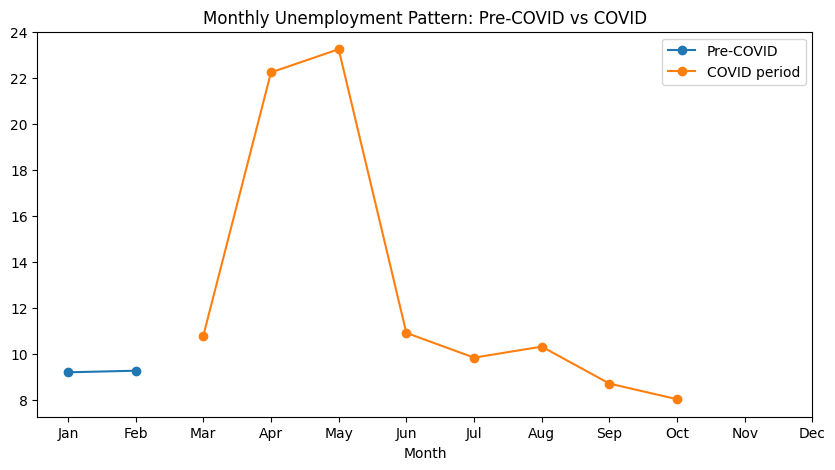

In [24]:
# Monthly pattern (aggregate across all years)
df['Month'] = df['Date'].dt.month
monthly_pattern = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10,4))
monthly_pattern.plot(marker='o')
plt.title("Seasonal Pattern: Average Unemployment by Month")
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

# Check if pattern is similar before vs during COVID
pre_covid = df[df['Date'] < '2020-03-01']
pre_monthly = pre_covid.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

covid_monthly = df[df['Date'] >= '2020-03-01'].groupby('Month')['Estimated Unemployment Rate (%)'].mean()

compare = pd.DataFrame({'Pre-COVID': pre_monthly, 'COVID period': covid_monthly})
compare.plot(marker='o', figsize=(10,5))
plt.title("Monthly Unemployment Pattern: Pre-COVID vs COVID")
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()

# Key Insights for Policy

In [25]:
# 1. Highest increase regions
print("Top 5 regions with highest COVID-led increase:")
print(regional_covid.nlargest(5, 'Change')[['Change']])

# 2. Regional disparity
print("Regional disparity (std dev of rates) pre-COVID vs during COVID:")
print(f"Pre-COVID: {pre_covid.groupby('Region')['Estimated Unemployment Rate (%)'].mean().std():.2f}")
print(f"During COVID: {df[df['IsCOVID']].groupby('Region')['Estimated Unemployment Rate (%)'].mean().std():.2f}")

Top 5 regions with highest COVID-led increase:
IsCOVID       Change
Region              
Puducherry  20.96500
Tamil Nadu  12.94625
Bihar       11.27625
Jharkhand   10.38625
Goa          7.89625
Regional disparity (std dev of rates) pre-COVID vs during COVID:
Pre-COVID: 7.31
During COVID: 6.33


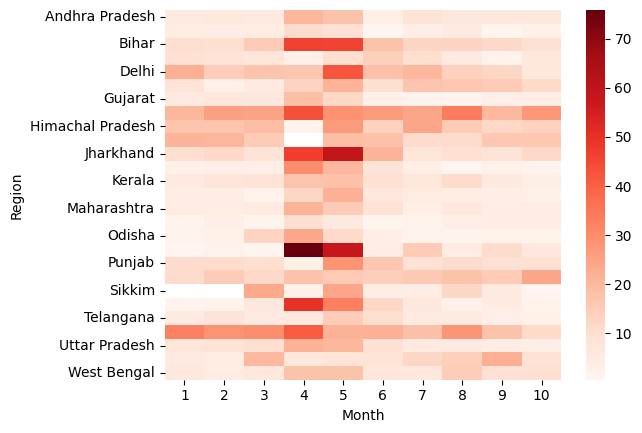

In [26]:
pivot = df.pivot_table(
    values='Estimated Unemployment Rate (%)',
    index='Region',
    columns='Month'
)

sns.heatmap(pivot, cmap='Reds')
plt.show()